In [111]:
import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [112]:
# Load household panel
hh = pd.read_csv("../data/target_data_pipeline.csv")

hh["month"] = pd.to_datetime(
    dict(year=hh["year"], month=hh["month"], day=1)
)

hh = hh[
    (hh["month"] >= "2008-01-01") &
    (hh["month"] <= "2016-12-31")
].copy()

hh["gps_longitude"] = pd.to_numeric(hh["gps_longitude"], errors="coerce")
hh["gps_latitude"] = pd.to_numeric(hh["gps_latitude"], errors="coerce")
hh = hh.dropna(subset=["gps_longitude", "gps_latitude"])

print("Total HH rows:", len(hh))

Total HH rows: 49796


In [114]:
df_tc = pd.read_parquet(
    "../data/processed/terraclimate_household_monthly_2008_2016.parquet"
)

df_tc["month"] = pd.to_datetime(df_tc["month"]).dt.to_period("M").dt.to_timestamp()

modis = pd.read_csv(
    "../data/processed/modis_household_monthly_2008_2016_20km.csv"
)

modis["month"] = pd.to_datetime(modis["month"]).dt.to_period("M").dt.to_timestamp()

monthly_pred = df_tc.merge(
    modis,
    on=["hhid","month"],
    how="left"
).sort_values(["hhid","month"]).reset_index(drop=True)

In [115]:
targets = hh[[
    "hhid",
    "month",
    "tlu_loss"
]]

monthly_pred = monthly_pred.merge(
    targets,
    on=["hhid","month"],
    how="inner"
)

monthly_pred = monthly_pred.dropna(
    subset=["tlu_loss"]
).reset_index(drop=True)

In [116]:
predictor_cols = [
    "soil","ppt","pdsi","vpd",
    "ndvi","lai","lst"
]

# Interpolate per HH
monthly_pred[predictor_cols] = (
    monthly_pred
    .groupby("hhid")[predictor_cols]
    .transform(lambda x: x.interpolate().ffill().bfill())
)

# Lags
for col in predictor_cols:
    for lag in [1,2,3]:
        monthly_pred[f"{col}_lag{lag}"] = (
            monthly_pred
            .groupby("hhid")[col]
            .shift(lag)
        )

# Seasonality
monthly_pred["month_sin"] = np.sin(
    2*np.pi*monthly_pred["month"].dt.month/12
)
monthly_pred["month_cos"] = np.cos(
    2*np.pi*monthly_pred["month"].dt.month/12
)

monthly_pred = monthly_pred.dropna().reset_index(drop=True)

In [117]:
monthly_pred = monthly_pred.sort_values(
    ["hhid","month"]
).reset_index(drop=True)

global_mean = monthly_pred["tlu_loss"].mean()

monthly_pred["hhid_tlu_enc"] = (
    monthly_pred
    .groupby("hhid")["tlu_loss"]
    .apply(lambda x: x.shift().expanding().mean())
    .reset_index(level=0, drop=True)
)

monthly_pred["hhid_tlu_enc"] = (
    monthly_pred["hhid_tlu_enc"]
    .fillna(global_mean)
)

In [118]:
last_year = monthly_pred["month"].dt.year.max()

train = monthly_pred[
    monthly_pred["month"].dt.year < last_year
]

test = monthly_pred[
    monthly_pred["month"].dt.year == last_year
]

feature_cols = [
    c for c in monthly_pred.columns
    if c not in [
        "hhid","ADMIN2","month","tlu_loss"
    ]
]

X_train = train[feature_cols]
X_test  = test[feature_cols]

y_train = train["tlu_loss"]
y_test  = test["tlu_loss"]

reg_hh = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

reg_hh.fit(X_train, y_train)
y_pred_hh = reg_hh.predict(X_test)

print("\nHOUSEHOLD TLU RESULTS")
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred_hh)))
print("MAE:", mean_absolute_error(y_test,y_pred_hh))
print("R²:", r2_score(y_test,y_pred_hh))


HOUSEHOLD TLU RESULTS
RMSE: 1.2612776187954755
MAE: 0.561980533921806
R²: -0.4857483265615685


In [120]:
monthly_pred["tlu_loss"].describe()
monthly_pred["tlu_loss"].value_counts().head(10)

tlu_loss
0.0    38407
0.1     1425
0.2     1147
1.3      797
1.0      700
0.3      661
0.4      461
0.5      318
2.0      317
2.6      274
Name: count, dtype: int64

In [123]:
train = train[train["tlu_loss"] >= 0]
test  = test[test["tlu_loss"] >= 0]

In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Create binary target
train["loss_flag"] = (train["tlu_loss"] > 0).astype(int)
test["loss_flag"]  = (test["tlu_loss"] > 0).astype(int)

X_train = train[feature_cols]
X_test  = test[feature_cols]

y_train_cls = train["loss_flag"]
y_test_cls  = test["loss_flag"]

clf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # important for imbalance
)

clf.fit(X_train, y_train_cls)

# Predict probabilities
proba_test = clf.predict_proba(X_test)[:,1]
y_pred_cls = clf.predict(X_test)

print("\nSTAGE 1 — LOSS OCCURRENCE")
print("ROC AUC:", roc_auc_score(y_test_cls, proba_test))
print("Precision:", precision_score(y_test_cls, y_pred_cls))
print("Recall:", recall_score(y_test_cls, y_pred_cls))
print("F1:", f1_score(y_test_cls, y_pred_cls))
print("\nClassification Report:\n")
print(classification_report(y_test_cls, y_pred_cls))


STAGE 1 — LOSS OCCURRENCE
ROC AUC: 0.5363164523819988
Precision: 0.6666666666666666
Recall: 0.0260950605778192
F1: 0.05022421524663677

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.99      0.82      2481
           1       0.67      0.03      0.05      1073

    accuracy                           0.70      3554
   macro avg       0.68      0.51      0.44      3554
weighted avg       0.69      0.70      0.59      3554



In [127]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

train_nonzero = train[train["tlu_loss"] > 0].copy()
test_nonzero  = test[test["tlu_loss"] > 0].copy()

X_train_reg = train_nonzero[feature_cols]
X_test_reg  = test_nonzero[feature_cols]

y_train_reg = train_nonzero["tlu_loss"]
y_test_reg  = test_nonzero["tlu_loss"]

reg = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

reg.fit(X_train_reg, y_train_reg)

y_pred_reg = reg.predict(X_test_reg)

print("\nSTAGE 2 — SEVERITY (NON-ZERO ONLY)")
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("R²:", r2_score(y_test_reg, y_pred_reg))


STAGE 2 — SEVERITY (NON-ZERO ONLY)
RMSE: 2.116250477184454
MAE: 1.274606112664956
R²: -0.5398405557220018


In [128]:
# Predict severity for ALL test rows
severity_pred_all = reg.predict(X_test)

# Expected loss
expected_loss = proba_test * severity_pred_all

print("\nTWO-STAGE EXPECTED VALUE RESULTS")
print("RMSE:", np.sqrt(mean_squared_error(test["tlu_loss"], expected_loss)))
print("MAE:", mean_absolute_error(test["tlu_loss"], expected_loss))
print("R²:", r2_score(test["tlu_loss"], expected_loss))


TWO-STAGE EXPECTED VALUE RESULTS
RMSE: 1.2132556706322546
MAE: 0.7093651124535056
R²: -0.37476520228078414


In [140]:
y_train_log = np.log1p(train["tlu_loss"])
y_test_log  = np.log1p(test["tlu_loss"])

X_train = train[feature_cols]
X_test  = test[feature_cols]

reg_log = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

reg_log.fit(X_train, y_train_log)

# Predict log space
y_pred_log = reg_log.predict(X_test)

# Convert back
y_pred = np.expm1(y_pred_log)

In [141]:
print("\nLOG-TRANSFORM REGRESSION RESULTS")
print("RMSE:", np.sqrt(mean_squared_error(test["tlu_loss"], y_pred)))
print("MAE:", mean_absolute_error(test["tlu_loss"], y_pred))
print("R²:", r2_score(test["tlu_loss"], y_pred))


LOG-TRANSFORM REGRESSION RESULTS
RMSE: 1.0577184148524854
MAE: 0.3725044500458626
R²: -0.044874191328745594


In [142]:
# Extract feature importance
importances = reg_log.feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

print("Top 15 Predictors:")
print(importance_df.head(15))

Top 15 Predictors:
         feature  importance
30  hhid_tlu_enc    0.289518
14     pdsi_lag2    0.072152
2           pdsi    0.053226
13     pdsi_lag1    0.050279
25      lst_lag1    0.030549
12      ppt_lag3    0.028715
26      lst_lag2    0.027886
10      ppt_lag1    0.027330
6            lst    0.026839
15     pdsi_lag3    0.026817
1            ppt    0.026742
9      soil_lag3    0.026496
27      lst_lag3    0.025816
21     ndvi_lag3    0.025722
3            vpd    0.024267


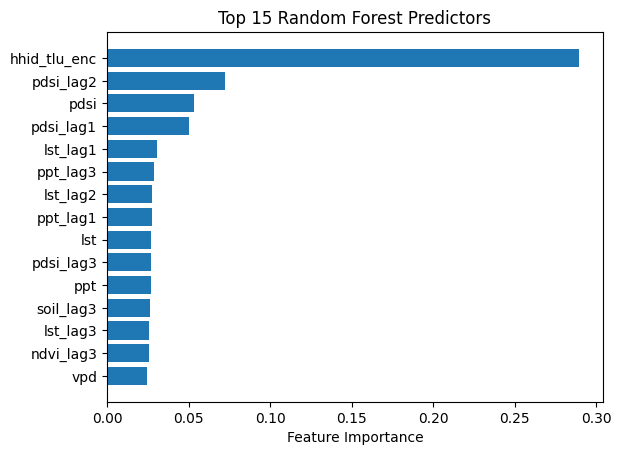

In [143]:
import matplotlib.pyplot as plt

top_n = 15
top_features = importance_df.head(top_n)

plt.figure()
plt.barh(top_features["feature"][::-1], 
         top_features["importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Random Forest Predictors")
plt.show()